# Titanic Survival Analysis

Performing exploratory data analysis (EDA) on the Titanic dataset to understand the factors that influenced passenger survival. Visualizing survival rates by class, gender, age, and more.

**Dataset:** Titanic Dataset
**Tools:** Pandas, Matplotlib, Seaborn

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 2. Load the Dataset

In [2]:
df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 3. Data Cleaning

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin'] = df['Cabin'].fillna('Unknown')
df['HasCabin'] = df['Cabin'].apply(lambda x: 0 if x == 'Unknown' else 1)
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
HasCabin       0
dtype: int64

In [7]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin,AgeGroup,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S,0,Young Adult,2
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,1,Adult,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S,0,Young Adult,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1,Young Adult,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S,0,Young Adult,1


## 4. Overall Survival Rate

Overall Survival Rate: 38.38%


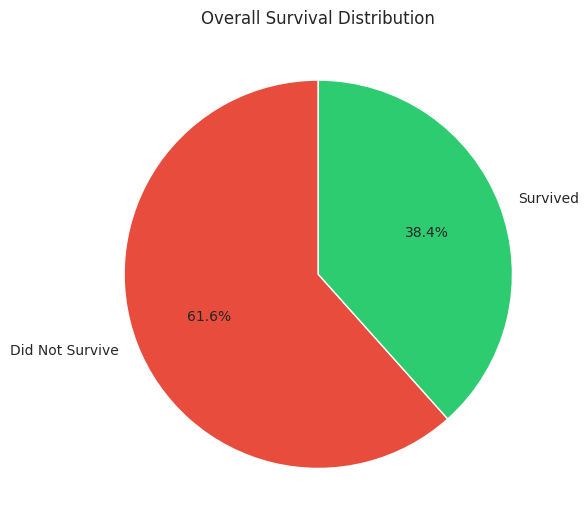

In [8]:
survival_rate = df['Survived'].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.2f}%")

plt.figure(figsize=(6, 6))
df['Survived'].value_counts().plot.pie(labels=['Did Not Survive', 'Survived'], autopct='%1.1f%%',
                                        colors=['#e74c3c', '#2ecc71'], startangle=90)
plt.title('Overall Survival Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

## 5. Survival by Passenger Class

In [9]:
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
class_survival

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

/tmp/ipykernel_545/2819082784.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Pclass', y='Survived', palette='Blues_d', errorbar=None)


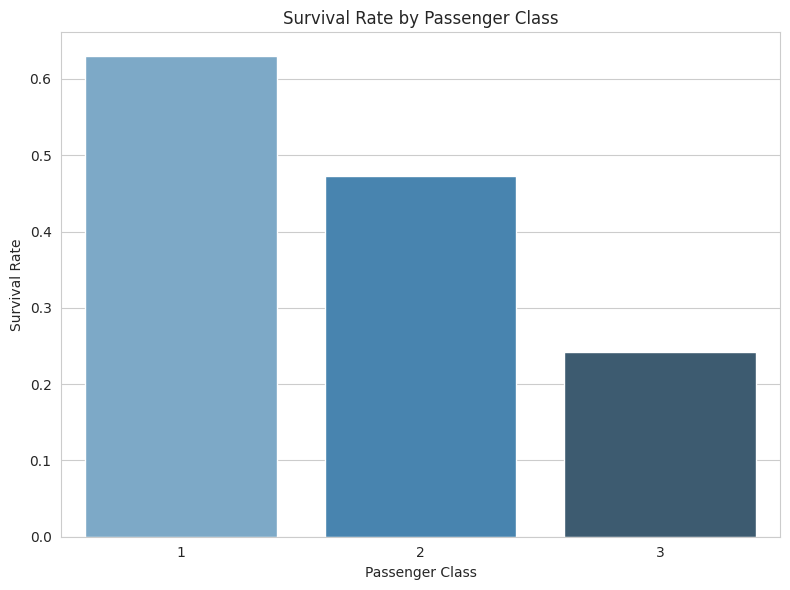

In [10]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Pclass', y='Survived', palette='Blues_d', errorbar=None)
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

## 6. Survival by Gender

In [11]:
gender_survival = df.groupby('Sex')['Survived'].mean() * 100
gender_survival

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

/tmp/ipykernel_545/2305434395.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Sex', y='Survived', palette=['#e74c3c', '#3498db'], errorbar=None)


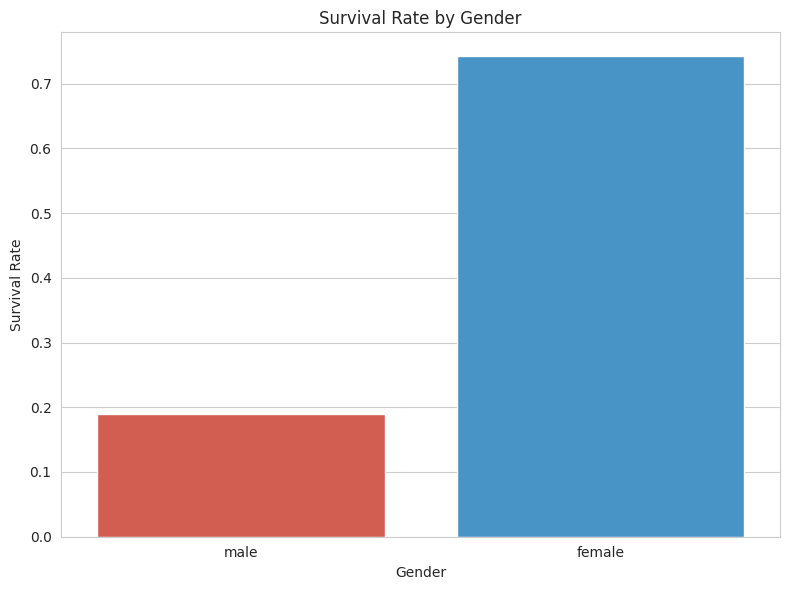

In [12]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Sex', y='Survived', palette=['#e74c3c', '#3498db'], errorbar=None)
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

## 7. Survival by Gender and Class

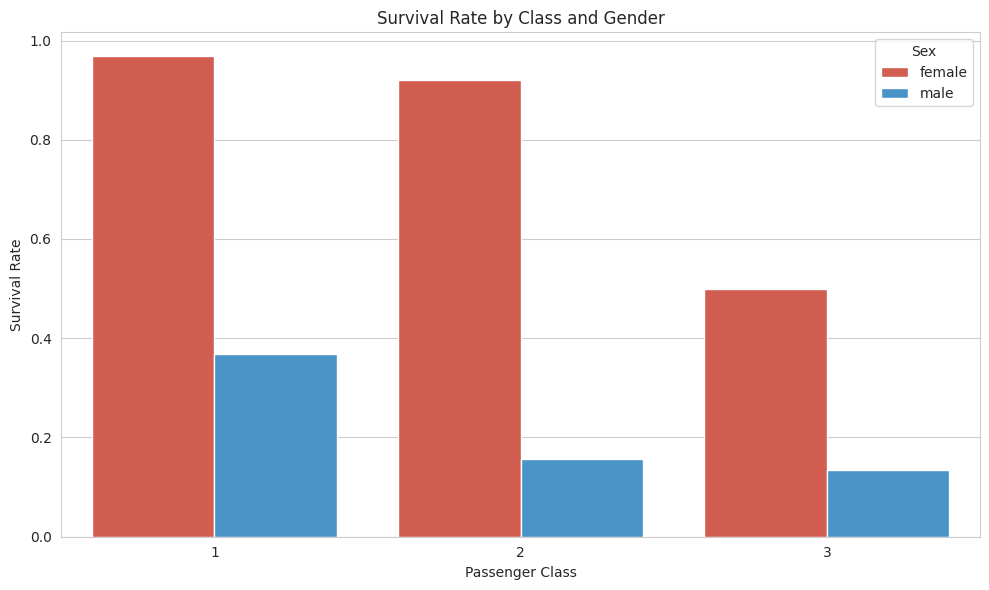

In [13]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex', palette=['#e74c3c', '#3498db'], errorbar=None)
plt.title('Survival Rate by Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

## 8. Age Distribution

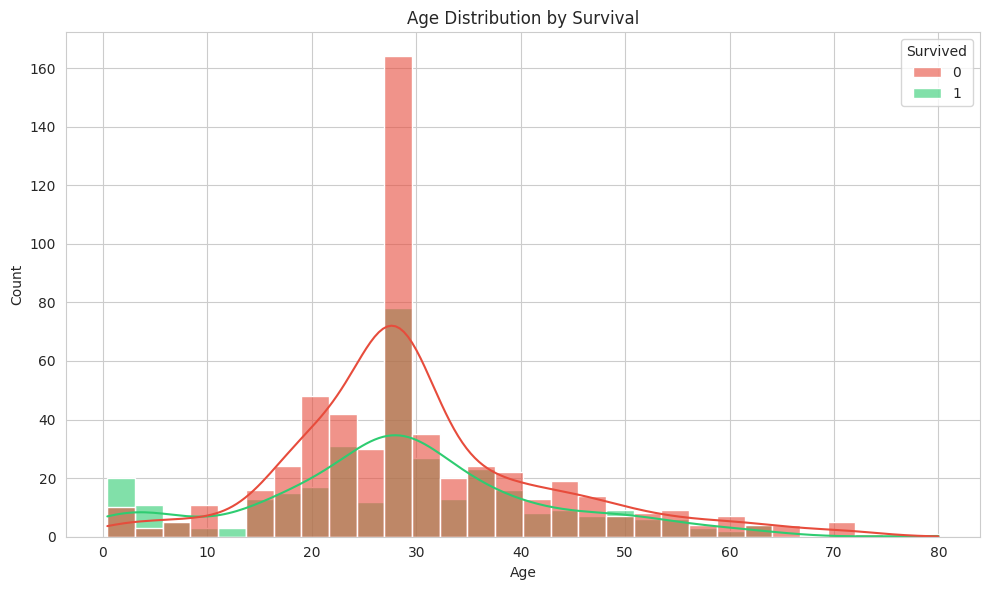

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, palette=['#e74c3c', '#2ecc71'], alpha=0.6)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

## 9. Survival by Age Group

/tmp/ipykernel_545/2490211291.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='AgeGroup', y='Survived', palette='viridis', errorbar=None)


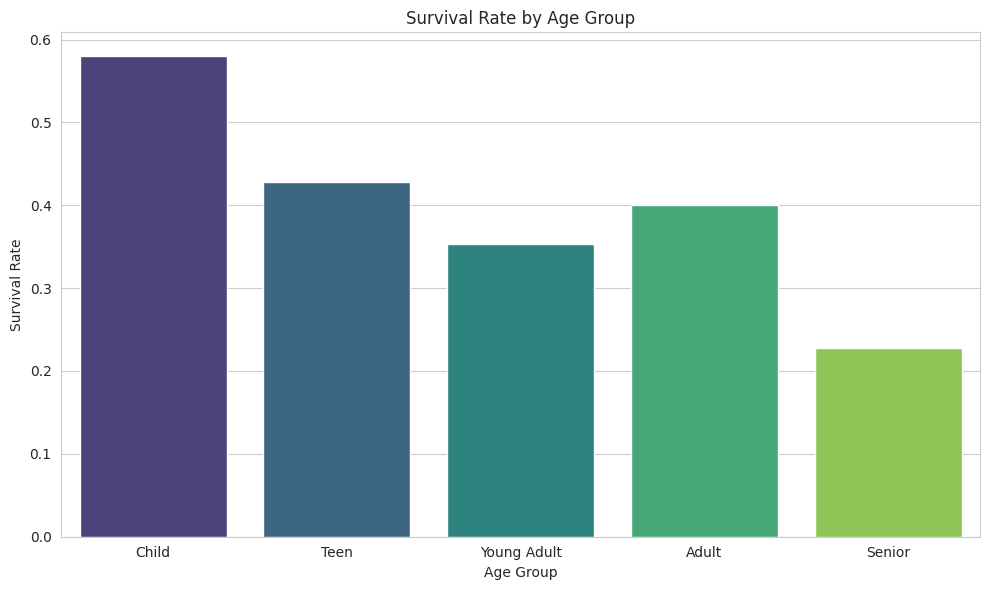

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='AgeGroup', y='Survived', palette='viridis', errorbar=None)
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

## 10. Survival by Family Size

/tmp/ipykernel_545/2373936163.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='FamilySize', y='Survived', palette='mako', errorbar=None)


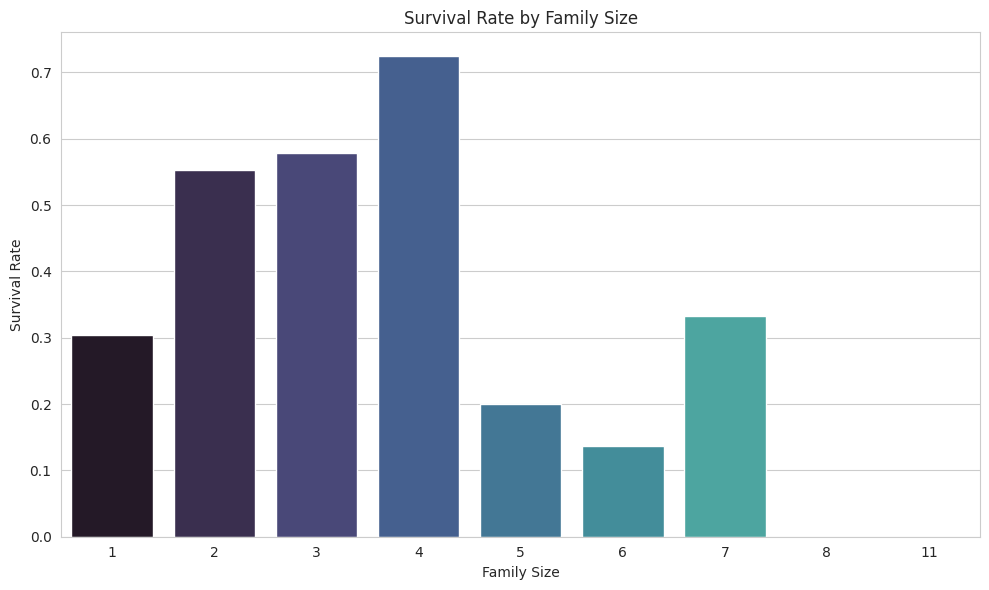

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='FamilySize', y='Survived', palette='mako', errorbar=None)
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

## 11. Fare Distribution by Survival

/tmp/ipykernel_545/3287172093.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Fare', palette=['#e74c3c', '#2ecc71'])


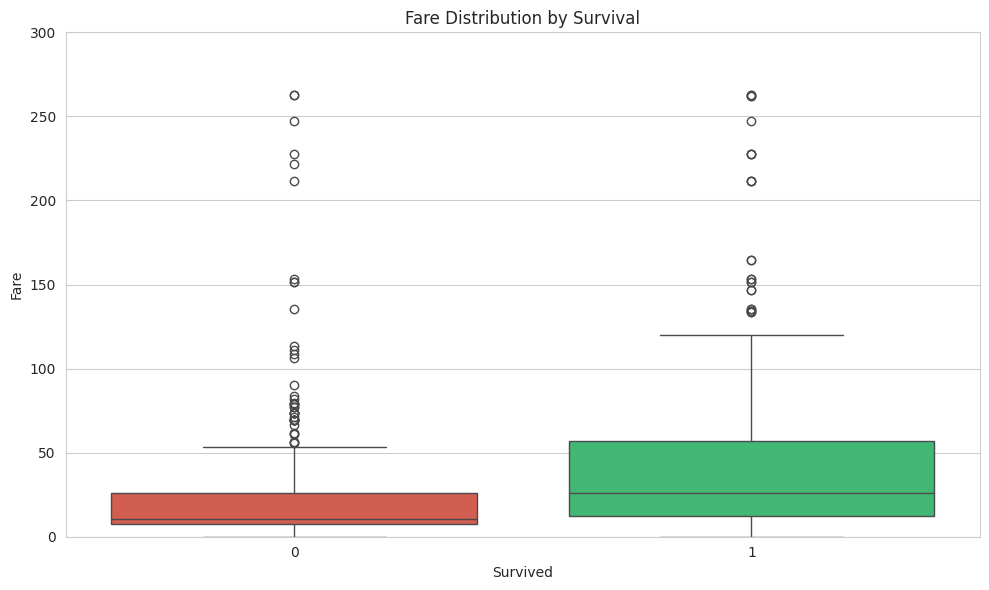

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Survived', y='Fare', palette=['#e74c3c', '#2ecc71'])
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived')
plt.ylabel('Fare')
plt.ylim(0, 300)
plt.tight_layout()
plt.show()

## 12. Survival by Embarkation Port

/tmp/ipykernel_545/1098974024.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Embarked', y='Survived', palette='crest', errorbar=None)


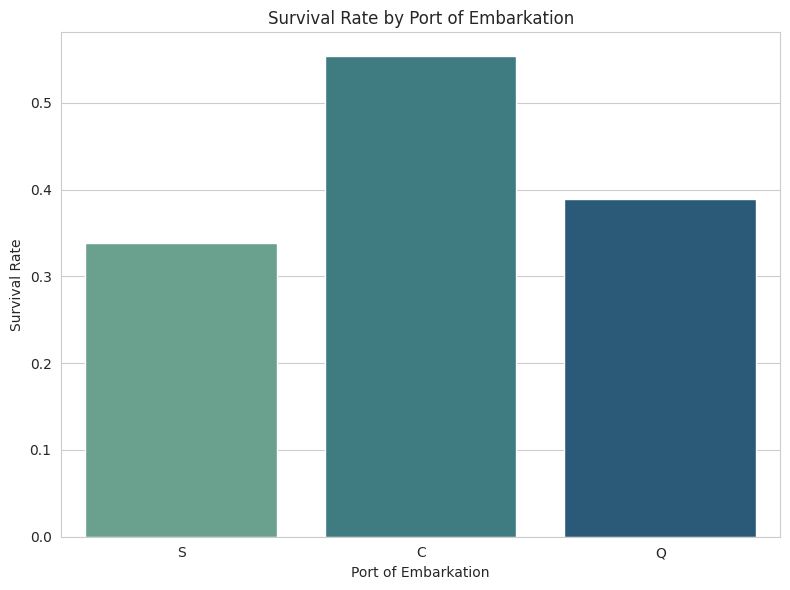

In [18]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='Embarked', y='Survived', palette='crest', errorbar=None)
plt.title('Survival Rate by Port of Embarkation')
plt.xlabel('Port of Embarkation')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

## 13. Effect of Having a Cabin Recorded

/tmp/ipykernel_545/162523053.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='HasCabin', y='Survived', palette='rocket', errorbar=None)


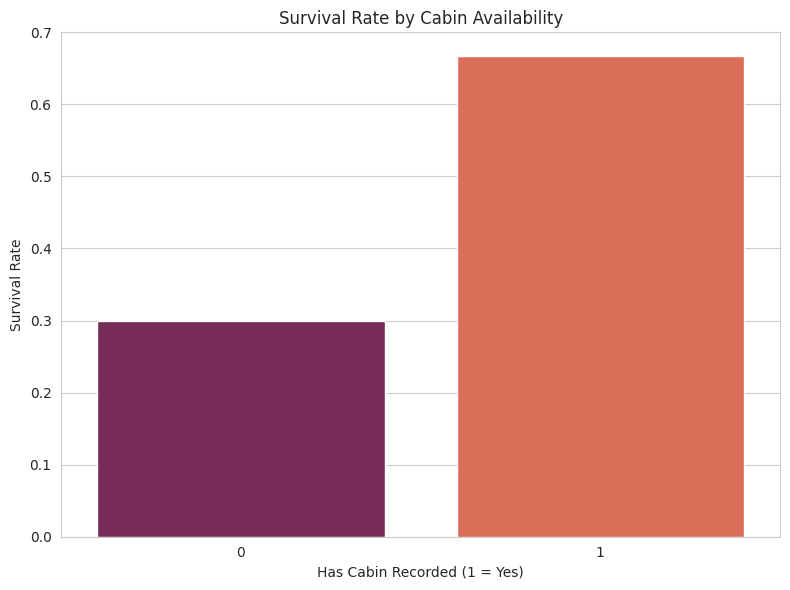

In [19]:
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x='HasCabin', y='Survived', palette='rocket', errorbar=None)
plt.title('Survival Rate by Cabin Availability')
plt.xlabel('Has Cabin Recorded (1 = Yes)')
plt.ylabel('Survival Rate')
plt.tight_layout()
plt.show()

## 14. Correlation Heatmap

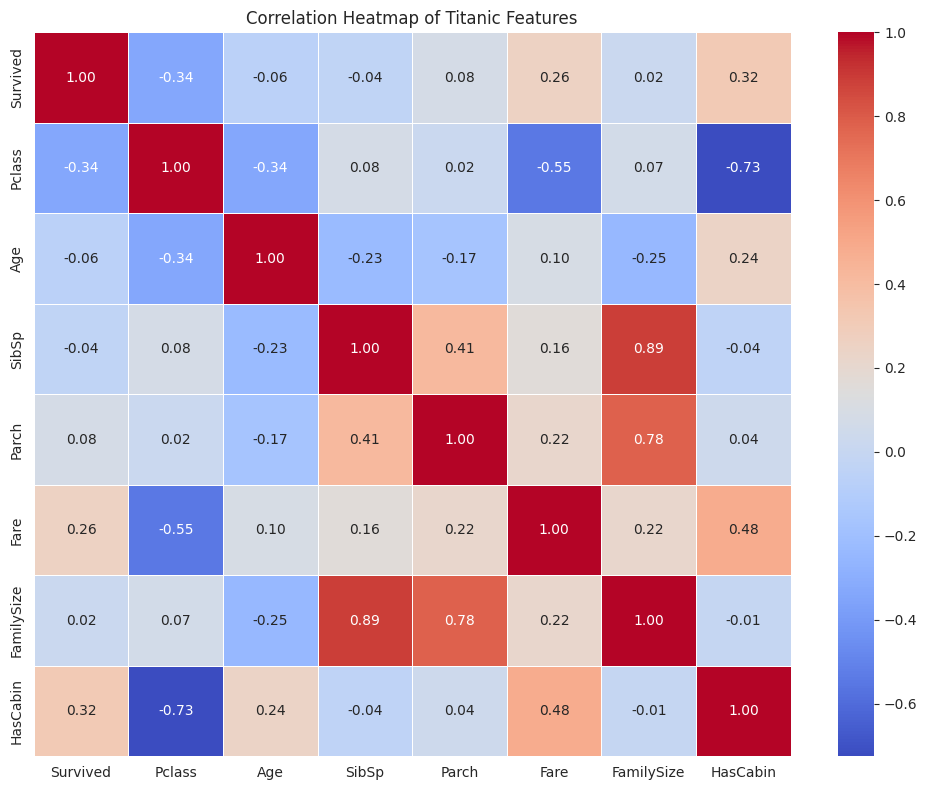

In [20]:
numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'HasCabin']]
corr = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Titanic Features')
plt.tight_layout()
plt.show()

## 15. Pairwise Relationships

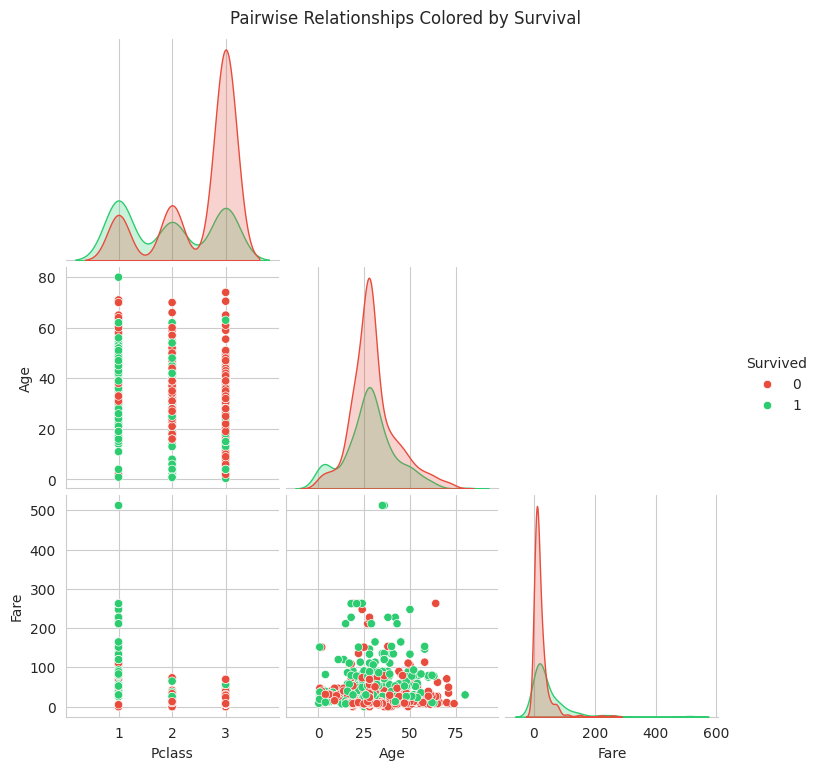

In [21]:
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare']], hue='Survived', palette=['#e74c3c', '#2ecc71'], corner=True)
plt.suptitle('Pairwise Relationships Colored by Survival', y=1.02)
plt.show()